In [1]:
import afqinsight as afqi
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
import pandas as pd
import scipy.stats as ss
import seaborn as sns

from groupyr.transform import GroupExtractor, GroupRemover, GroupResampler
from groupyr.decomposition import GroupPCA

import statsmodels.api as sm
from statsmodels.gam.api import GLMGam, BSplines
from statsmodels.stats.multitest import fdrcorrection

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from neurocombat_sklearn import CombatModel

from tqdm.auto import tqdm

In [2]:
workdir = "../data/nles_apq_cbcl_wisc_0.0/"
target_cols = [
    "Age", "Sex", "Barratt_Total",
    "NLES_P_TotalEvents", "NLES_P_Upset_Total",
    "APQ_SR_CP", "APQ_P_CP",
    "APQ_SR_Total", "APQ_P_Total",
    "CBCL_Ext", "CBCL_Int", "CBCL_Total",
    "WISC_FSIQ", "WISC_WMI", "WISC_PSI", "WISC_FRI",
    "CBCL_25", "CBCL_37", "CBCL_38", "CBCL_48",
]

In [3]:
afqdata = afqi.load_afq_data(
    workdir=workdir,
    dwi_metrics=["dki_fa", "dki_md"],
    target_cols=target_cols,
    fn_nodes="tract_profiles_merged.csv",
    fn_subjects="pheno_merged.csv",
    return_bundle_means=False
)

Z = afqdata.X
Y = afqdata.y
groups = afqdata.groups
feature_names = afqdata.feature_names
group_names = afqdata.group_names
subjects = afqdata.subjects

afqdata_means = afqi.load_afq_data(
    workdir=workdir,
    dwi_metrics=["dki_fa", "dki_md"],
    target_cols=target_cols,
    fn_nodes="tract_profiles_merged.csv",
    fn_subjects="pheno_merged.csv",
    return_bundle_means=True
)
Z_mean = afqdata_means.X
groups_mean = afqdata_means.groups
feature_names_mean = afqdata_means.feature_names
group_names_mean = afqdata_means.group_names

In [4]:
print(Z.shape)
print(Y.shape)
print(len(subjects))

(756, 4800)
(756, 20)
756


In [5]:
df_qc = pd.read_csv(op.join(workdir, "qc_merged.csv"), index_col="subjectID").reindex(subjects)

df_qc["scan_site_index"] = df_qc["scan_site_id"].map({
    "RU": 0.0,
    "CBIC": 1.0,
    "CUNY": 2.0,
})

In [6]:
df_Y = pd.DataFrame(data=Y, columns=target_cols, index=subjects)
df_Y["CBCL_PV"] = df_Y[["CBCL_25", "CBCL_37", "CBCL_38", "CBCL_48"]].sum(axis="columns")
df_Y.drop(["CBCL_25", "CBCL_37", "CBCL_38", "CBCL_48"], inplace=True, axis="columns")

In [7]:
n_pca_components = 5
resample_nodes = 40

In [8]:
imputer = SimpleImputer(strategy="median")
Z_imputed = imputer.fit_transform(Z)
Z_mean_imputed = imputer.fit_transform(Z_mean)

grs = GroupResampler(resample_to=resample_nodes, groups=groups, group_names=group_names)
Z_rs = grs.fit_transform(Z_imputed)

gpca = GroupPCA(n_components=n_pca_components, groups=groups)
Z_pca = gpca.fit_transform(Z_imputed)

combat = CombatModel()
continuous_cols = [
    "Age", "Barratt_Total",
    "NLES_P_TotalEvents", "NLES_P_Upset_Total", 
    "APQ_P_CP", "APQ_SR_CP", "APQ_P_Total", "APQ_SR_Total",
    "CBCL_PV", "CBCL_Int", "CBCL_Ext", "CBCL_Total",
    "WISC_FSIQ", "WISC_WMI", "WISC_PSI", "WISC_FRI"
]

Z_harmonized = combat.fit_transform(
    Z_imputed,
    df_qc["scan_site_index"].to_numpy().reshape(-1, 1),
    df_Y[["Sex"]],
    df_Y[continuous_cols]
)

Z_rs_harmonized = combat.fit_transform(
    Z_rs,
    df_qc["scan_site_index"].to_numpy().reshape(-1, 1),
    df_Y[["Sex"]],
    df_Y[continuous_cols]
)

Z_mean_harmonized = combat.fit_transform(
    Z_mean_imputed,
    df_qc["scan_site_index"].to_numpy().reshape(-1, 1),
    df_Y[["Sex"]],
    df_Y[continuous_cols]
)

Z_pca_harmonized = combat.fit_transform(
    Z_pca,
    df_qc["scan_site_index"].to_numpy().reshape(-1, 1),
    df_Y[["Sex"]],
    df_Y[continuous_cols]
)

In [9]:
pca_features = []
for grp_name in group_names:
    for idx in range(n_pca_components):
        pca_features.append(grp_name + ("pc" + str(idx),))

In [10]:
def stringify(features):
    return ["__".join([str(f) for f in feat]) for feat in features]

In [11]:
df_Z = pd.DataFrame(data=Z_harmonized, columns=stringify(feature_names), index=subjects)
df_Z_pca = pd.DataFrame(data=Z_pca_harmonized, columns=stringify(pca_features), index=subjects)
df_Z_rs = pd.DataFrame(data=Z_rs_harmonized, columns=stringify(grs.feature_names_out_), index=subjects)
df_Z_mean = pd.DataFrame(data=Z_mean_harmonized, columns=stringify(feature_names_mean), index=subjects)

In [12]:
def residualize_age_sex_ses(Z, Y):
    df_combined = pd.merge(Z, Y, right_index=True, left_index=True)

    age_ses_scaler = StandardScaler(with_std=True)
    df_combined[["Age", "Barratt_Total"]] = age_ses_scaler.fit_transform(df_combined[["Age", "Barratt_Total"]])

    df_Z_resid = Z.copy()
    df_Z_resid_intercept = df_Z_resid.copy()

    for col in tqdm(df_Z_resid.columns):
        glm = sm.GLM.from_formula(
            f"{col} ~ Age + C(Sex) + Barratt_Total",
            data=df_combined,
        )

        res_bs = glm.fit()
        df_Z_resid[col] -= res_bs.predict()
        df_Z_resid_intercept[col] -= (res_bs.predict() - res_bs.params.Intercept)
        
    df_Y_resid = Y.copy()
    df_Y_resid[["Age", "Barratt_Total"]] = age_ses_scaler.fit_transform(df_Y_resid[["Age", "Barratt_Total"]])
    
    for col in tqdm(df_Y_resid.columns):
        if col in ["Age", "Sex", "Barratt_Total"]:
            continue

        glm = sm.GLM.from_formula(
            f"{col} ~ Age + C(Sex) + Barratt_Total",
            data=df_Y_resid,
        )

        res_bs = glm.fit()
        df_Y_resid[col] -= res_bs.predict()

    df_Y_resid[["Age", "Barratt_Total"]] = age_ses_scaler.inverse_transform(df_Y_resid[["Age", "Barratt_Total"]])

    return {
        "Z_resid": df_Z_resid,
        "Z_resid_with_intercept": df_Z_resid_intercept,
        "Y_resid": df_Y_resid,
        "Z_orig": Z,
        "Y_orig": Y,
    }

In [13]:
resid = residualize_age_sex_ses(df_Z, df_Y)
resid_pca = residualize_age_sex_ses(df_Z_pca, df_Y)
resid_rs = residualize_age_sex_ses(df_Z_rs, df_Y)
resid_mean = residualize_age_sex_ses(df_Z_mean, df_Y)

  0%|          | 0/4800 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/1920 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

In [14]:
def calculate_nested_f_statistic(small_model, big_model):
    """Given two fitted GLMs, the larger of which contains the parameter space of the smaller, return the F Stat and P value corresponding to the larger model adding explanatory power"""
    addtl_params = big_model.df_model - small_model.df_model
    f_stat = (small_model.deviance - big_model.deviance) / (addtl_params * big_model.scale)
    df_numerator = addtl_params
    # use fitted values to obtain n_obs from model object:
    df_denom = (big_model.fittedvalues.shape[0] - big_model.df_model)
    p_value = ss.f.sf(f_stat, df_numerator, df_denom)
    return (f_stat, p_value)

In [15]:
def glm_f_test(
    Z, Y, Z_column,
    model_formula, model_columns,
    null_formula, null_columns,
    n_basis=4, spline_order=3,
    use_gam=True
):
    df_combined = pd.merge(Z, Y, right_index=True, left_index=True)

    if use_gam:
        _X1 = df_combined[model_columns]
        bs1 = BSplines(
            _X1,
            df=[n_basis] * len(model_columns),
            degree=[spline_order] * len(model_columns)
        )
        m1 = GLMGam.from_formula(
            f"{Z_column} ~ {model_formula}",
            data=df_combined,
            smoother=bs1,
        )
        
        if len(null_columns):
            _X0 = df_combined[null_columns]
            bs0 = BSplines(
                _X0,
                df=[n_basis] * len(null_columns),
                degree=[spline_order] * len(null_columns)
            )
            m0 = GLMGam.from_formula(
                f"{Z_column} ~ {null_formula}",
                data=df_combined,
                smoother=bs0,
            )
        else:
            m0 = sm.GLM.from_formula(
                f"{Z_column} ~ 1",
                data=df_combined,
            )
    else:
        m1 = sm.GLM.from_formula(
            f"{Z_column} ~ {model_formula}",
            data=df_combined,
        )
        m0 = sm.GLM.from_formula(
            f"{Z_column} ~ {null_formula}",
            data=df_combined,
        )
    
    fit0 = m0.fit()
    fit1 = m1.fit()
    
    f_stat, p_val = calculate_nested_f_statistic(fit0, fit1)
    
    return {
        "F-test": f_stat,
        "p-val": p_val,
        "model": m1,
        "fit": fit1,
    }

In [19]:
def bundle_f_tests(
    Z, Y,
    model_formula, model_columns,
    null_formula, null_columns,
    n_basis=4, spline_order=3,
    use_gam=True,
):
    features = Z.columns
    
    models = {}
    fit_results = {}
    
    f_test_dicts = []
    for Z_col in tqdm(features):
        f_results = glm_f_test(
            Z=Z,
            Y=Y,
            Z_column=Z_col,
            model_formula=model_formula,
            model_columns=model_columns,
            null_formula=null_formula,
            null_columns=null_columns,
            n_basis=n_basis,
            spline_order=spline_order,
            use_gam=use_gam,
        )

        f_test_dicts.append({
            "F-test": f_results["F-test"],
            "p-val": f_results["p-val"],
        })
        
        models[Z_col] = f_results["model"]
        fit_results[Z_col] = f_results["fit"]
    
    df = pd.DataFrame(
        data=f_test_dicts,
        index=features
    )
    
    rejected, corrected = fdrcorrection(df["p-val"])
    df["fdr-corrected-p-val"] = corrected
    df["null-rejected"] = rejected
    
    return df, models, fit_results

In [22]:
df_age, age_models, age_fits = bundle_f_tests(
    Z=resid_pca["Z_orig"],
    Y=resid_pca["Y_orig"],
    model_formula="1 + Age",
    model_columns=["Age"],
    null_formula="1",
    null_columns=[],
    n_basis=4, spline_order=3,
    use_gam=False
)
df_age

  0%|          | 0/240 [00:00<?, ?it/s]

,F-test,p-val,fdr-corrected-p-val,null-rejected
dki_fa__ARC_L__pc0,63.312080,6.456741e-15,3.443595e-14,True
dki_fa__ARC_L__pc1,0.971529,3.246149e-01,3.914953e-01,False
dki_fa__ARC_L__pc2,46.241487,2.125977e-11,8.797148e-11,True
dki_fa__ARC_L__pc3,0.643942,4.225394e-01,4.852127e-01,False
dki_fa__ARC_L__pc4,7.590051,6.010480e-03,1.015856e-02,True
...,...,...,...,...
dki_md__UNC_R__pc0,75.955510,1.824611e-17,1.183531e-16,True
dki_md__UNC_R__pc1,0.548040,4.593496e-01,5.200185e-01,False
dki_md__UNC_R__pc2,2.874098,9.042770e-02,1.261782e-01,False
dki_md__UNC_R__pc3,2.452878,1.177287e-01,1.614564e-01,False


In [26]:
df_upset_glm, upset_glm_models, upset_glm_fits = bundle_f_tests(
    Z=resid_pca["Z_orig"],
    Y=resid_pca["Y_orig"],
    model_formula="1 + Age + NLES_P_Upset_Total + Age:NLES_P_Upset_Total",
    model_columns=["Age", "NLES_P_Upset_Total"],
    null_formula="1 + Age",
    null_columns=["Age"],
    n_basis=4, spline_order=3,
    use_gam=False
)

  0%|          | 0/240 [00:00<?, ?it/s]

In [27]:
df_upset_gam, upset_gam_models, upset_gam_fits = bundle_f_tests(
    Z=resid_pca["Z_orig"],
    Y=resid_pca["Y_orig"],
    model_formula="1 + Age + NLES_P_Upset_Total + Age:NLES_P_Upset_Total",
    model_columns=["Age", "NLES_P_Upset_Total"],
    null_formula="1 + Age",
    null_columns=["Age"],
    n_basis=4, spline_order=3,
    use_gam=True
)

  0%|          | 0/240 [00:00<?, ?it/s]

In [31]:
df = pd.merge(
    df_upset_gam,
    df_upset_glm,
    left_index=True,
    right_index=True,
    suffixes=["_gam", "_glm"]
)
df[df["null-rejected_gam"]]

,F-test_gam,p-val_gam,fdr-corrected-p-val_gam,null-rejected_gam,F-test_glm,p-val_glm,fdr-corrected-p-val_glm,null-rejected_glm
dki_md__SupFrontal__pc4,6.822588,0.000021,0.005138,True,4.695113,0.009409,0.376364,False


In [34]:
bundles

Index(['dki_md__SupFrontal__pc4'], dtype='object')

TypeError: 'AxesSubplot' object is not subscriptable

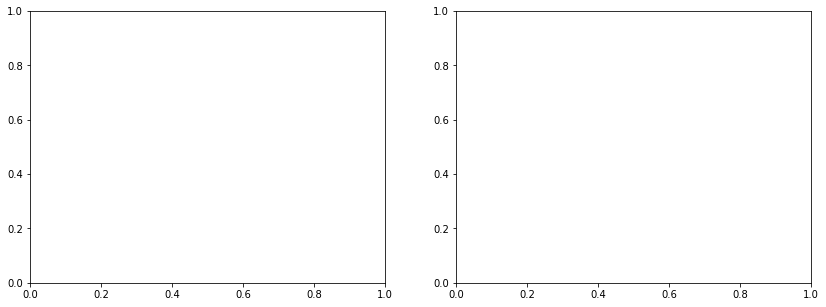

In [33]:
bundles = df[df["null-rejected_gam"]].index

fig, axes = plt.subplots(len(bundles), 2, figsize=(14, 5 * len(bundles)))

behavioral_feature = "NLES_P_Upset_Total"
df_combined = resid_pca["Y_orig"].copy()
df_combined["Age"] = np.around(df_combined["Age"] * 2, decimals=0) / 2
df_combined["NLES_bin"] = pd.qcut(df_combined[behavioral_feature], q=2)

for bundle in bundles:
    df_combined[bundle + "_prediction"] = upset_gam_fits[bundle].predict()
    df_combined[bundle + "_observed"] = resid_pca["Z_orig"][bundle]

df_combined = df_combined[df_combined["Age"] <= 16.0]
    
for bundle, ax_row in zip(bundles, axes):
    _ = sns.lineplot(
        x="Age",
        y=bundle + "_observed",
        data=df_combined,
        hue="NLES_bin",
        ax=ax_row[0],
        ci=95.0,
    )

    _ = sns.lineplot(
        x="Age",
        y=bundle + "_prediction",
        data=df_combined,
        hue="NLES_bin",
        ax=ax_row[1],
        ci=95.0
    )